# Synthetic macro-financial simulation

This notebook builds a simple, transparent data-generating process for the MSc thesis simulation study. For now it only creates synthetic time-series data and diagnostics. It does not implement PTO, DFL, or decision-only black-box models.

The baseline structure is:

```text
x_{t-1} -> p_t -> s_t -> c_t -> alpha_t^oracle
```

Here `p_t` is the latent true probability of stress implied by lagged macro-financial predictors, while `s_t` is the realised binary stress draw. They are deliberately different quantities: many quarters can have elevated stress probability without entering realised stress, and stress can occasionally occur when the probability is not extreme.


## 1. Imports and shared capital-allocation functions

This section imports only standard scientific Python tools plus the project's shared capital-allocation utilities. The oracle allocation is computed using the same realised-utility logic as the empirical notebooks, rather than rewriting the utility objective inside this notebook.


In [88]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.stats import truncnorm
import matplotlib.pyplot as plt

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")

pd.set_option("display.max_columns", 100)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "models" / "src").exists() and (candidate / "models" / "simulation" / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")


REPO_ROOT = find_repo_root()
MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

from capital_allocation_utils import CapitalConfig, annualised_pd_from_chargeoff, irb_capital_requirement

print(f"Repo root: {REPO_ROOT}")


Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New


## 2. Configuration

The macro variables are fully simulated using a stable VAR(1) process. The stress-probability coefficients, VAR persistence, covariance matrix, sample length, burn-in, and charge-off distribution parameters are controlled here.

The empirical calibration currently enters through the regime charge-off means in `CapitalConfig`. Replace `mu_normal`, `mu_stress`, `sigma_normal`, and `sigma_stress` below with final empirical estimates when they are available. The standard deviations are calibrated simulation parameters, not fixed structural constants.


In [99]:
MACRO_NAMES = ["activity", "labour_market_stress", "financial_conditions"]


@dataclass
class SimulationConfig:
    """Configuration for the synthetic DGP."""

    T: int = 500
    burn_in: int = 200
    start_date: str = "2000-01-01"
    freq: str = "QS"

    # Stable VAR(1) parameters for x_t = A x_{t-1} + epsilon_t.
    A: np.ndarray = field(default_factory=lambda: np.array([
    [0.92, -0.03, -0.02],
    [-0.02, 0.90, 0.05],
    [-0.02, 0.06, 0.90],
    ], dtype=float))

    Sigma_x: np.ndarray = field(default_factory=lambda: np.array([
        [0.03, -0.008, -0.006],
        [-0.008, 0.025, 0.009],
        [-0.006, 0.009, 0.028],
    ], dtype=float))

    # Stress equation: higher activity reduces stress; higher labour stress and
    # tighter financial conditions increase stress.
    gamma_0: float = -2.0
    gamma: np.ndarray = field(default_factory=lambda: np.array([-1.5, 1.8, 1.6], dtype=float))
    # TODO: Insert final empirical regime estimates here when available.
    # Values are decimal quarterly charge-off rates. Defaults come from CapitalConfig.
    mu_normal: float = CapitalConfig().mu_normal
    mu_stress: float = CapitalConfig().mu_stress
    sigma_normal: float = CapitalConfig().sigma_normal
    sigma_stress: float = CapitalConfig().sigma_stress



    capital: CapitalConfig = field(default_factory=lambda: CapitalConfig(lgd=0.45, leverage=10.0))
    alpha_grid_size: int = 1001

    rho = 0.8

    # Determines stress period persistence
    q11: float = 0.8

config = SimulationConfig()

print("VAR eigenvalue moduli:", np.round(np.abs(np.linalg.eigvals(config.A)), 3))
print("Sigma_x eigenvalues:", np.round(np.linalg.eigvalsh(config.Sigma_x), 3))
print("Stress equation gamma:", dict(zip(MACRO_NAMES, config.gamma)))
print(config)


VAR eigenvalue moduli: [0.973 0.901 0.845]
Sigma_x eigenvalues: [0.017 0.023 0.043]
Stress equation gamma: {'activity': np.float64(-1.5), 'labour_market_stress': np.float64(1.8), 'financial_conditions': np.float64(1.6)}
SimulationConfig(T=500, burn_in=200, start_date='2000-01-01', freq='QS', A=array([[ 0.92, -0.03, -0.02],
       [-0.02,  0.9 ,  0.05],
       [-0.02,  0.06,  0.9 ]]), Sigma_x=array([[ 0.03 , -0.008, -0.006],
       [-0.008,  0.025,  0.009],
       [-0.006,  0.009,  0.028]]), gamma_0=-2.0, gamma=array([-1.5,  1.8,  1.6]), mu_normal=0.0061, mu_stress=0.0143, sigma_normal=0.0042, sigma_stress=0.0067, capital=CapitalConfig(lgd=0.45, y_bar=0.05, lambda_penalty=10.0, maturity=2.5, leverage=10.0, mu_normal=0.0061, sigma_normal=0.0042, mu_stress=0.0143, sigma_stress=0.0067, pd_floor=1e-06, pd_cap=0.99, alpha_eps=1e-08), alpha_grid_size=1001, q11=0.8)


## 3. Charge-off truncation check

Charge-offs are drawn from zero-truncated normal distributions using `scipy.stats.truncnorm`. The configured `mu_*` values are treated as the location parameters of the underlying normal distributions. This cell reports the actual means after truncation so the effect of the lower bound is visible.


In [100]:
def lower_truncnorm_params(mu: float, sigma: float, lower: float = 0.0) -> tuple[float, float, float, float]:
    a = (lower - mu) / sigma
    b = np.inf
    return a, b, mu, sigma


def truncated_normal_mean(mu: float, sigma: float, lower: float = 0.0) -> float:
    a, b, loc, scale = lower_truncnorm_params(mu, sigma, lower)
    return float(truncnorm.mean(a, b, loc=loc, scale=scale))


truncation_summary = pd.DataFrame({
    "regime": ["normal", "stress"],
    "underlying_mu": [config.mu_normal, config.mu_stress],
    "underlying_sigma": [config.sigma_normal, config.sigma_stress],
    "actual_truncated_mean": [
        truncated_normal_mean(config.mu_normal, config.sigma_normal),
        truncated_normal_mean(config.mu_stress, config.sigma_stress),
    ],
})
truncation_summary["truncation_shift"] = truncation_summary["actual_truncated_mean"] - truncation_summary["underlying_mu"]
display(truncation_summary)


,regime,underlying_mu,underlying_sigma,actual_truncated_mean,truncation_shift
0,normal,0.0061,0.0042,0.006730,0.000630
1,stress,0.0143,0.0067,0.014579,0.000279


## 4. Simulation functions

The function `simulate_dataset(config, seed)` generates a genuinely synthetic time series. It first simulates persistent correlated macro predictors, then uses lagged macro variables to construct `p_t`, draws realised stress regimes `s_t`, draws zero-truncated charge-offs `c_t`, and finally computes the oracle allocation from realised charge-offs.

The output row dated `time = t` contains predictors observed at `t-1`, followed by the realised target-quarter stress probability, regime, charge-off rate, and oracle allocation.


In [101]:
def simulate_macro_path(config: SimulationConfig, rng: np.random.Generator) -> np.ndarray:
    total_x = config.T + config.burn_in + 1
    x = np.zeros((total_x, len(MACRO_NAMES)), dtype=float)
    for t in range(1, total_x):
        eps_t = rng.multivariate_normal(mean=np.zeros(len(MACRO_NAMES)), cov=config.Sigma_x)
        x[t] = config.A @ x[t - 1] + eps_t
    return x


def draw_lower_truncated_normal(
    rng: np.random.Generator,
    mu: np.ndarray,
    sigma: np.ndarray,
    lower: float = 0.0,
) -> np.ndarray:
    a = (lower - mu) / sigma
    b = np.full_like(a, np.inf, dtype=float)
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, random_state=rng)

def draw_chargeoffs_ar1(s, rng, config):
    """
    c_t = rho * c_{t-1} + (1 - rho) * mu_{s_t} + eta_t
    eta_t ~ N(0, sigma_{s_t}^2 * (1 - rho^2))
    """
    T = len(s)
    c = np.zeros(T)
    mu = np.where(s == 1, config.mu_stress, config.mu_normal)
    sigma = np.where(s == 1, config.sigma_stress, config.sigma_normal)
    
    c[0] = mu[0]
    for t in range(1, T):
        innovation_std = sigma[t] * np.sqrt(1 - config.rho**2)
        c[t] = config.rho * c[t-1] + (1 - config.rho) * mu[t] + rng.normal(0, innovation_std)
    
    return np.maximum(c, 0.0)  # floor at zero


def oracle_alpha_grid(realised_c: float, config: SimulationConfig) -> float:
    alpha_grid = np.linspace(0.0, 1.0, config.alpha_grid_size)
    cfg = config.capital
    pd_a = float(annualised_pd_from_chargeoff(realised_c, cfg))
    k_irb = float(irb_capital_requirement(pd_a, cfg))
    ell = cfg.leverage

    terminal_capital = 1.0 + alpha_grid * ell * (cfg.y_bar - realised_c)
    available_buffer = alpha_grid * ell * (cfg.y_bar - realised_c) + (1.0 - alpha_grid)
    required_capital = k_irb * alpha_grid * ell
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    utilities = terminal_capital - cfg.lambda_penalty * shortfall
    return float(alpha_grid[int(np.argmax(utilities))])


def draw_markov_regimes(p, rng, q11:float):
    """
    p    : T-length array of entry probabilities
    q11  : P(stay in stress | currently in stress)
    """
    T = len(p)
    s = np.zeros(T, dtype=int)
    s[0] = rng.binomial(1, p[0])
    for t in range(1, T):
        if s[t-1] == 1:
            s[t] = rng.binomial(1, q11)
        else:
            s[t] = rng.binomial(1, p[t])
    return s


def simulate_dataset(config: SimulationConfig, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    x = simulate_macro_path(config, rng)

    x_lag = x[:-1]
    logits = config.gamma_0 + x_lag @ config.gamma
    p = expit(logits)
    s = draw_markov_regimes(p, rng, config.q11)

    chargeoff_mu = np.where(s == 1, config.mu_stress, config.mu_normal)
    chargeoff_sigma = np.where(s == 1, config.sigma_stress, config.sigma_normal)
    #chargeoffs = draw_chargeoffs_ar1(s, rng, config)
    chargeoffs = draw_lower_truncated_normal(rng, chargeoff_mu, chargeoff_sigma, lower=0.0)
    
    keep = slice(config.burn_in, config.burn_in + config.T)
    dates = pd.date_range(config.start_date, periods=config.T, freq=config.freq)

    df = pd.DataFrame(x_lag[keep], columns=MACRO_NAMES)
    df.insert(0, "time", dates)
    df["true_stress_probability"] = p[keep]
    df["stress_regime"] = s[keep]
    df["charge_off_rate"] = chargeoffs[keep]
    df["oracle_alpha"] = [oracle_alpha_grid(float(c), config) for c in df["charge_off_rate"]]

    # Compatibility aliases for the existing simulation PTO / black-box notebooks.
    df["DATE"] = df["time"]
    df["sim_persistent_stress_indicator"] = df["labour_market_stress"]
    df["sim_noisy_leading_indicator"] = df["financial_conditions"]
    df["sim_noisy_leading_indicator_lag1"] = df["activity"]
    df["sim_irrelevant_noise"] = 0.0
    df["sim_true_stress_probability"] = df["true_stress_probability"]
    df["sim_target_regime"] = df["stress_regime"]
    df["regime"] = df["stress_regime"]
    df["sim_charge_off_rate"] = df["charge_off_rate"]
    df["sim_chargeoff"] = df["charge_off_rate"]
    df["sim_oracle_alpha"] = df["oracle_alpha"]

    return df


sim_df = simulate_dataset(config, seed=1)
display(sim_df.head())
display(sim_df[["activity", "labour_market_stress", "financial_conditions", "true_stress_probability", "stress_regime", "charge_off_rate", "oracle_alpha"]].describe().T)


,time,activity,labour_market_stress,financial_conditions,true_stress_probability,stress_regime,charge_off_rate,oracle_alpha,DATE,sim_persistent_stress_indicator,sim_noisy_leading_indicator,sim_noisy_leading_indicator_lag1,sim_irrelevant_noise,sim_true_stress_probability,sim_target_regime,regime,sim_charge_off_rate,sim_chargeoff,sim_oracle_alpha
0,2000-01-01,-0.113077,1.235935,0.046236,0.614976,1,0.022379,0.385,2000-01-01,1.235935,0.046236,-0.113077,0.0,0.614976,1,1,0.022379,0.022379,0.385
1,2000-04-01,-0.179695,0.800771,0.074599,0.457674,0,0.002787,0.666,2000-04-01,0.800771,0.074599,-0.179695,0.0,0.457674,0,0,0.002787,0.002787,0.666
2,2000-07-01,-0.337556,0.567994,0.258778,0.485696,1,0.011411,0.466,2000-07-01,0.567994,0.258778,-0.337556,0.0,0.485696,1,1,0.011411,0.011411,0.466
3,2000-10-01,-0.246880,0.685362,0.206689,0.483674,0,0.012402,0.454,2000-10-01,0.685362,0.206689,-0.246880,0.0,0.483674,0,0,0.012402,0.012402,0.454
4,2001-01-01,-0.389701,0.669565,-0.135259,0.394927,1,0.023767,0.379,2001-01-01,0.669565,-0.135259,-0.389701,0.0,0.394927,1,1,0.023767,0.023767,0.379


,count,mean,std,min,25%,50%,75%,max
activity,500.0,-0.006158,0.462064,-1.116638,-0.335309,0.000999,0.337006,1.104439
labour_market_stress,500.0,-0.005252,0.440426,-1.182595,-0.324875,0.044155,0.329457,1.235935
financial_conditions,500.0,-0.024821,0.426950,-1.081780,-0.348704,-0.070109,0.297739,1.099502
true_stress_probability,500.0,0.209230,0.232477,0.001608,0.037100,0.110260,0.299188,0.943201
stress_regime,500.0,0.390000,0.488238,0.000000,0.000000,0.000000,1.000000,1.000000
charge_off_rate,500.0,0.010015,0.006647,0.000060,0.005160,0.008441,0.013338,0.036391
oracle_alpha,500.0,0.528222,0.121431,0.350000,0.443750,0.511000,0.584000,1.000000


## 5. Diagnostic summaries

These summaries check whether the simulated data have meaningful stress episodes, plausible charge-off dispersion, a non-degenerate oracle allocation, and the intended predictive direction from macro variables to future outcomes.


In [102]:
def stress_episode_lengths(stress_regime: pd.Series) -> list[int]:
    values = stress_regime.astype(int).to_numpy()
    lengths = []
    current = 0
    for value in values:
        if value == 1:
            current += 1
        elif current > 0:
            lengths.append(current)
            current = 0
    if current > 0:
        lengths.append(current)
    return lengths


def future_correlations(df: pd.DataFrame, macro_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in macro_cols:
        rows.append({
            "macro_variable": col,
            "corr_with_future_stress_regime": df[col].corr(df["stress_regime"]),
            "corr_with_future_charge_off_rate": df[col].corr(df["charge_off_rate"]),
        })
    return pd.DataFrame(rows)


episode_lengths = stress_episode_lengths(sim_df["stress_regime"])
summary = pd.Series({
    "overall_stress_frequency": sim_df["stress_regime"].mean(),
    "number_of_stress_episodes": len(episode_lengths),
    "average_stress_episode_length": np.mean(episode_lengths) if episode_lengths else 0.0,
    "min_charge_off_rate": sim_df["charge_off_rate"].min(),
    "max_charge_off_rate": sim_df["charge_off_rate"].max(),
    "oracle_alpha_mean": sim_df["oracle_alpha"].mean(),
    "oracle_alpha_std": sim_df["oracle_alpha"].std(),
})

print("Main diagnostics")
display(summary.to_frame("value"))

print("Charge-off rate by realised regime")
display(sim_df.groupby("stress_regime")["charge_off_rate"].agg(["count", "mean", "std", "min", "max"]))

print("Macro correlations with future realised outcomes")
display(future_correlations(sim_df, MACRO_NAMES))


Main diagnostics


,value
overall_stress_frequency,0.390000
number_of_stress_episodes,38.000000
average_stress_episode_length,5.131579
min_charge_off_rate,0.000060
max_charge_off_rate,0.036391
oracle_alpha_mean,0.528222
oracle_alpha_std,0.121431


Charge-off rate by realised regime


,count,mean,std,min,max
stress_regime,,,,,
0,305,0.006622,0.003729,0.000081,0.020047
1,195,0.015323,0.006742,0.000060,0.036391


Macro correlations with future realised outcomes


,macro_variable,corr_with_future_stress_regime,corr_with_future_charge_off_rate
0,activity,-0.499709,-0.324867
1,labour_market_stress,0.519467,0.348817
2,financial_conditions,0.415148,0.286179


## 6. Diagnostic plots

The plots show the simulated macro predictors, the distinction between true stress probability and realised stress, realised charge-offs with stress periods shaded, the oracle allocation, charge-off distributions by regime, and the relationship between true stress probability and realised charge-offs.


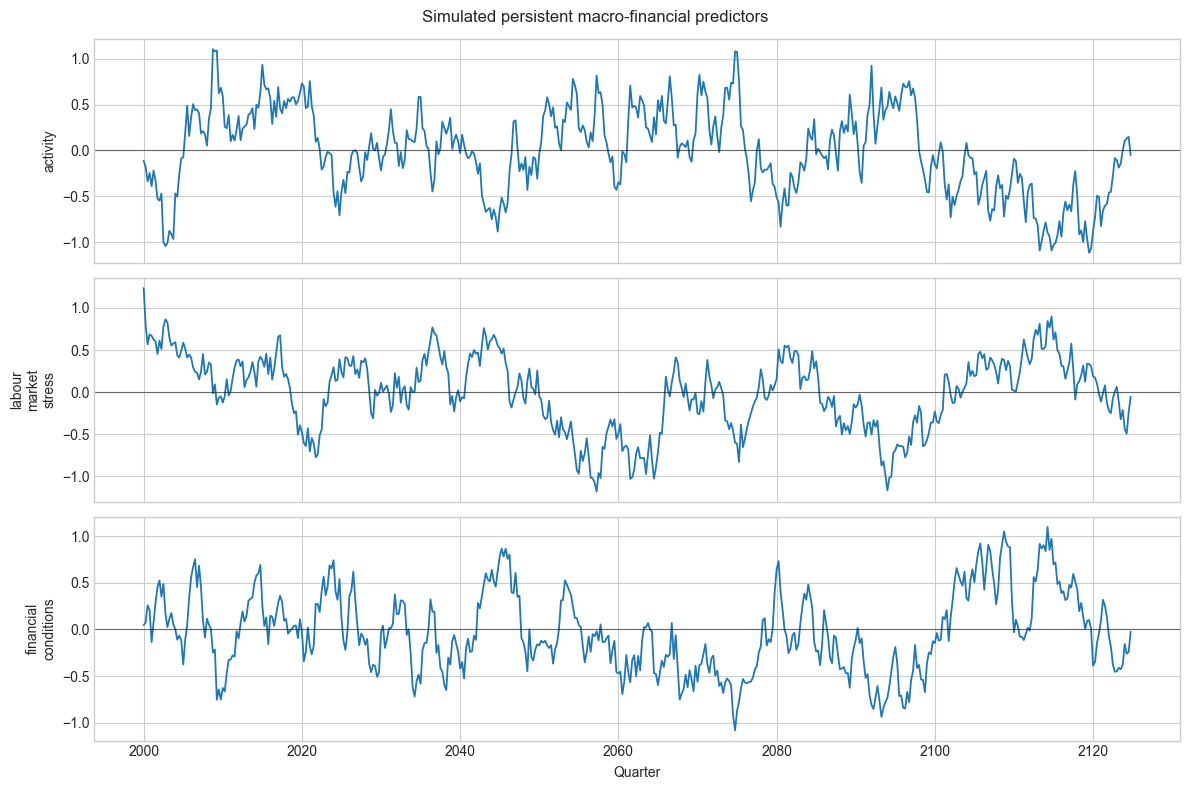

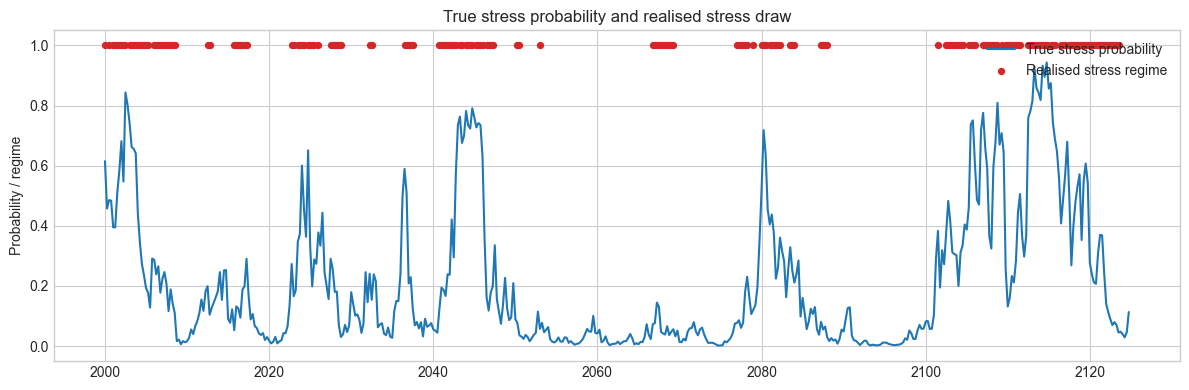

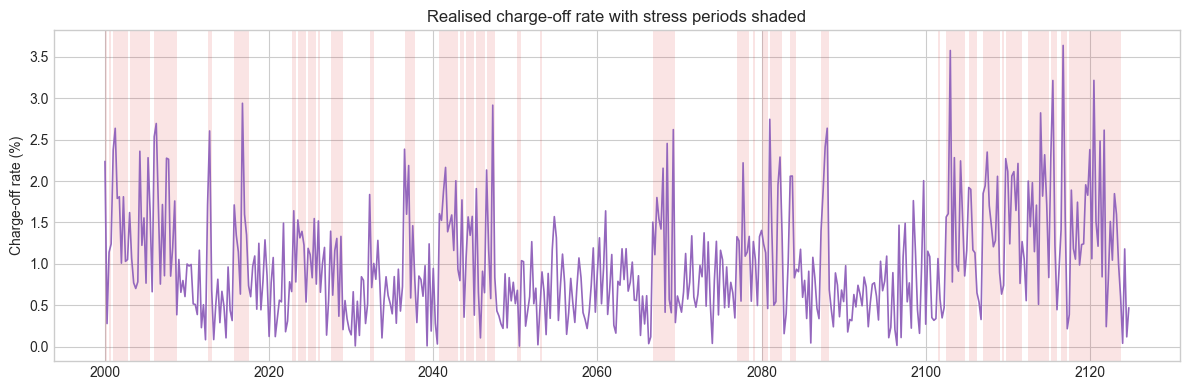

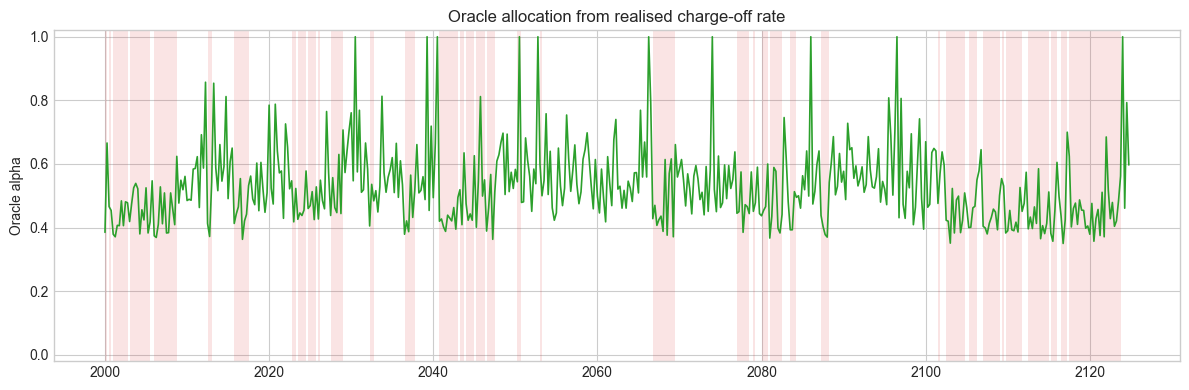

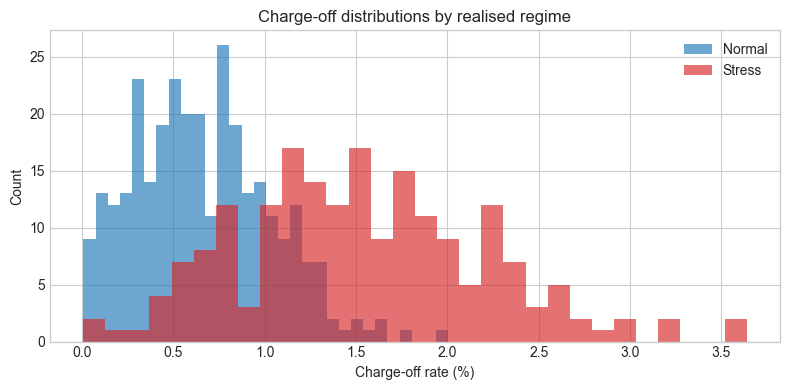

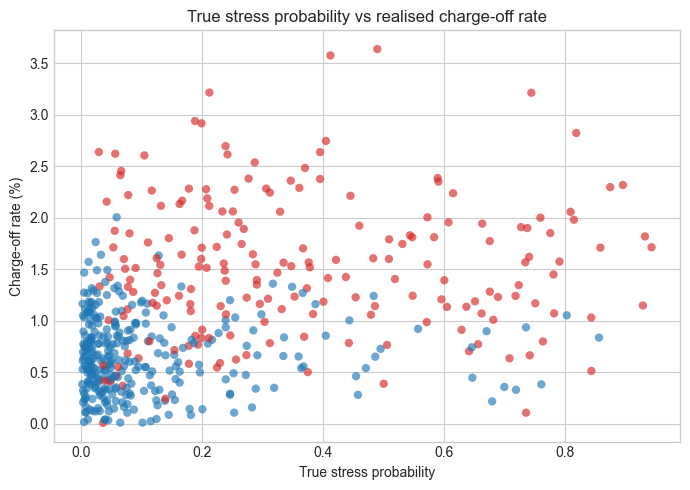

In [103]:
def shade_stress_periods(ax, df: pd.DataFrame, color: str = "tab:red", alpha: float = 0.12) -> None:
    in_stress = False
    start = None
    times = df["time"].to_numpy()
    regimes = df["stress_regime"].to_numpy(dtype=int)

    for i, regime in enumerate(regimes):
        if regime == 1 and not in_stress:
            start = times[i]
            in_stress = True
        is_last = i == len(regimes) - 1
        if in_stress and (regime == 0 or is_last):
            end_idx = i if regime == 0 else i
            end = times[end_idx]
            ax.axvspan(start, end, color=color, alpha=alpha, linewidth=0)
            in_stress = False


fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, col in zip(axes, MACRO_NAMES):
    ax.plot(sim_df["time"], sim_df[col], linewidth=1.3)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_ylabel(col.replace("_", "\n"))
axes[-1].set_xlabel("Quarter")
fig.suptitle("Simulated persistent macro-financial predictors", y=0.98)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sim_df["time"], sim_df["true_stress_probability"], color="tab:blue", label="True stress probability")
ax.scatter(
    sim_df.loc[sim_df["stress_regime"].eq(1), "time"],
    sim_df.loc[sim_df["stress_regime"].eq(1), "stress_regime"],
    color="tab:red",
    s=18,
    label="Realised stress regime",
)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("Probability / regime")
ax.set_title("True stress probability and realised stress draw")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
shade_stress_periods(ax, sim_df)
ax.plot(sim_df["time"], 100 * sim_df["charge_off_rate"], color="tab:purple", linewidth=1.2)
ax.set_ylabel("Charge-off rate (%)")
ax.set_title("Realised charge-off rate with stress periods shaded")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
shade_stress_periods(ax, sim_df)
ax.plot(sim_df["time"], sim_df["oracle_alpha"], color="tab:green", linewidth=1.2)
ax.set_ylim(-0.02, 1.02)
ax.set_ylabel("Oracle alpha")
ax.set_title("Oracle allocation from realised charge-off rate")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for regime, label, color in [(0, "Normal", "tab:blue"), (1, "Stress", "tab:red")]:
    values = 100 * sim_df.loc[sim_df["stress_regime"].eq(regime), "charge_off_rate"]
    ax.hist(values, bins=30, alpha=0.65, label=label, color=color)
ax.set_xlabel("Charge-off rate (%)")
ax.set_ylabel("Count")
ax.set_title("Charge-off distributions by realised regime")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
colors = np.where(sim_df["stress_regime"].eq(1), "tab:red", "tab:blue")
ax.scatter(sim_df["true_stress_probability"], 100 * sim_df["charge_off_rate"], c=colors, alpha=0.65, edgecolor="none")
ax.set_xlabel("True stress probability")
ax.set_ylabel("Charge-off rate (%)")
ax.set_title("True stress probability vs realised charge-off rate")
fig.tight_layout()
plt.show()


In [7]:
output_dir = REPO_ROOT / "models" / "simulation" / "data"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "simulated_variables.csv"
sim_df.to_csv(output_path, index=False)
print(f"Saved {len(sim_df)} rows to {output_path.relative_to(REPO_ROOT)}")

required_columns = [
    "time",
    "activity",
    "labour_market_stress",
    "financial_conditions",
    "true_stress_probability",
    "stress_regime",
    "charge_off_rate",
    "oracle_alpha",
]
display(sim_df[required_columns].head())


Saved 500 rows to models/simulation/data/simulated_variables.csv


,time,activity,labour_market_stress,financial_conditions,true_stress_probability,stress_regime,charge_off_rate,oracle_alpha
0,2000-01-01,-0.233461,1.375665,-0.459927,0.346239,0,0.012135,0.457
1,2000-04-01,-0.362790,0.760180,0.490140,0.424864,0,0.003942,0.621
2,2000-07-01,0.081477,0.251652,0.518976,0.242494,0,0.011362,0.466
3,2000-10-01,-0.255237,1.035646,0.184373,0.403124,1,0.006165,0.558
4,2001-01-01,-0.121132,0.972103,0.830311,0.495556,0,0.007996,0.519
